In [1]:
import re
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

# For Gausian Process Regression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C

In [2]:
# extraction functions
def extract_data_lines(file, pattern):
    extracted_lines = []
    with open(file, 'r', encoding='utf-8') as f:
        for line in f:
            if pattern.search(line.strip()):
                extracted_lines.append(line.strip())
    return extracted_lines

def clean_data(extracted_lines):
    cleaned_data = []
    for line in extracted_lines:
        # a. Preprocessing: Remove non-data text (comments, descriptions).
        line_part = line.strip()
        if ':' in line_part:
            line_part = line_part.split(':', 1)[1].strip()
        if '(' in line_part:
            line_part = line_part.split('(', 1)[0].strip()
    
        # b. Cleaning: Remove '%' and convert all other delimiters (like ',') to space.
        cleaned_line = line_part.replace('%', '').replace(',', ' ').strip()
        
        # c. Extraction: Find all numbers (sequences of digits).
        numbers_str = re.findall(r'\d+', cleaned_line)
        
        # d. Conversion: Convert to list of floats.
        numeric_lst = [float(n) for n in numbers_str]

        cleaned_data.append(numeric_lst)
    return cleaned_data

# Turn any set of decimal forecasts into percentage values
def scale_data(cleaned_data):
    scaled_data = []
    for line in cleaned_data:
        if np.average(line) < 1.0:
            scaled_lst = [n*100 for n in line]
        else:
            scaled_lst = line
        scaled_data.append(scaled_lst)
    return scaled_data

def make_sorted_single_lst(data_lst):
    single_lst = []
    for line in data_lst:
        single_lst += line
    sorted_data = sorted(single_lst).copy()
    return sorted_data

def make_percentiles(sorted_data):
    pctl = [100 * i/(1 + len(sorted_data)) for i, row in enumerate(sorted_data)]
    return pctl

In [3]:
# input files for extraction
#question_ids = [39945, 39929, 39956, 39938]
question_ids = [39945, 39929, 39956, 39938, 39954, 39936, 39952, 39926, 39951, 39932, 39931, 39935, 39950, 39953, 39980, 39943, 39949, 
                39955, 39981, 39933, 39979, 39927, 39930, 39982, 39934, 39958, 39986, 39937, 39957, 39946, 39940, 39947, 39924, 39944,
                39985, 39983, 39939, 39984, 39996, 40020]

pattern = re.compile(r'^(?:[^:\r\n]*:\s*)?\s*(\d{1,2}\s*\%?\s*[,]\s*){6,8}\d{1,2}\s*\%?.*$')
path = "Data"

### Forecast Distribution Notes
The forecast scenarios after sorting are "blocky" in two ways. First, the forecasts were directed to use 1% precision, so every prediction falls on an 1% value. Worse, the model itself strongly prefers prefers 5% increments.

#### Solution
Do some sort of curve fit that smooths through the block forecast. That should improve forecast accuracy by a couple of percent. 

#### Fit Candidates
- Gaussian Process Regression https://scikit-learn.org/stable/modules/gaussian_process.html
- Kernel Ridge Regression (KRR): https://scikit-learn.org/stable/modules/kernel_ridge.html
- Support Vector Regression (SVR): https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html#sklearn.svm.SVR
    - Difficult for more than 10,000 points
    - Default kernal degree is 3 (similar to spline I learned in college?)
- Scipy Interpolate: https://docs.scipy.org/doc/scipy/reference/interpolate.html


In [4]:
# Gaussian Process Function
## Gaussian Process Regression: https://www.geeksforgeeks.org/machine-learning/quick-start-to-gaussian-process-regression/
## Note my display has percentile on vertical axis, but for regression I need percentile to be X
def make_gpr_model(sorted_data, pctl):
    X = np.array(pctl).reshape(-1, 1)
    y = np.array(sorted_data)
    
    # 1. Define the base smooth kernel (e.g., a Constant * RBF)
    # The ConstantKernel (C) scales the magnitude of the function
    smooth_kernel = C(1.0, (1e-3, 1e5)) * RBF(20.0, (1e-2, 1e2))
    
    # 2. Add the WhiteKernel to model the noise/blockiness
    # The WhiteKernel parameter (noise_level) will be optimized to capture the variance of the blockiness
    kernel = smooth_kernel + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e2))
    
    # 3. Fit the model
    # The optimizer will now find the best fit for the RBF parameters AND the noise_level
    gp_model  = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
    gp_model.fit(X,y)

    return gp_model

def calc_gpr(gp_model):
    y_pred, sigma_pred = gp_model.predict(X, return_std=True)
    return y_pred, sigma_pred

def calc_gpr_p50(gp_model):
    return gp_model.predict(np.array([50]))



In [5]:
# Plot function
def plot_forecast():
    plt.title(f"{file}")
    plt.scatter(sorted_data, pctl, s=4)
    plt.plot(predicted_val, pctl, label=f"forecast p50 = {np.round(forecast_p50[0],2)}")
    plt.xlabel("forecast value")
    plt.xticks(range(0,101,10))
    plt.ylabel("percentile")
    plt.yticks(range(0,101,10))
    plt.grid()
    plt.legend()
    plt.show()

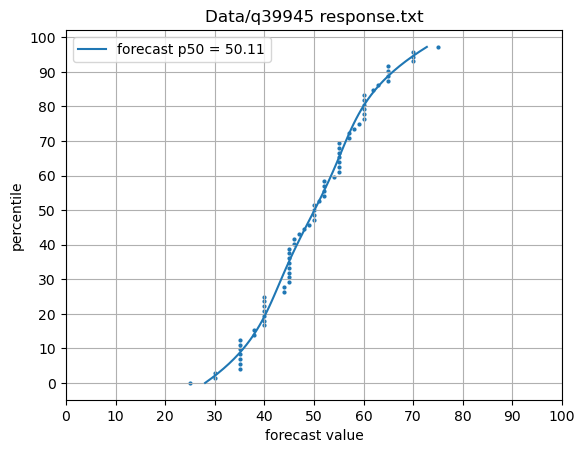

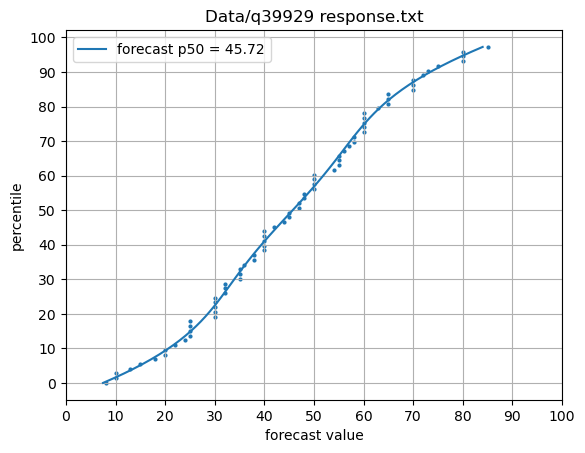

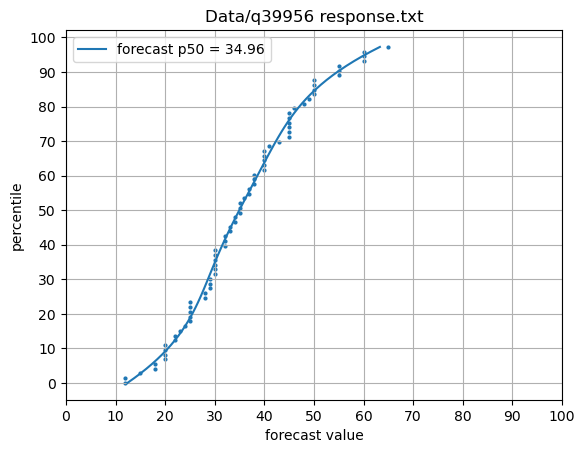

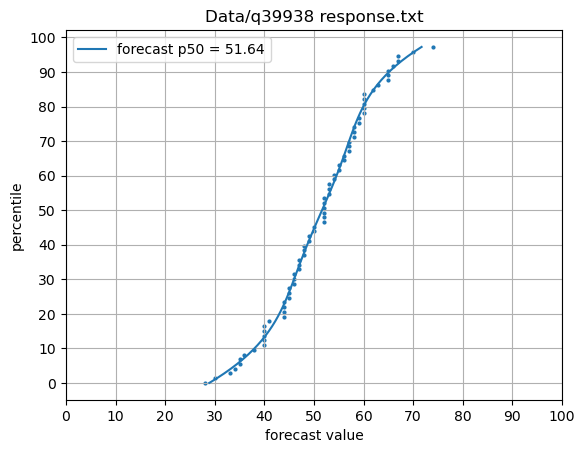

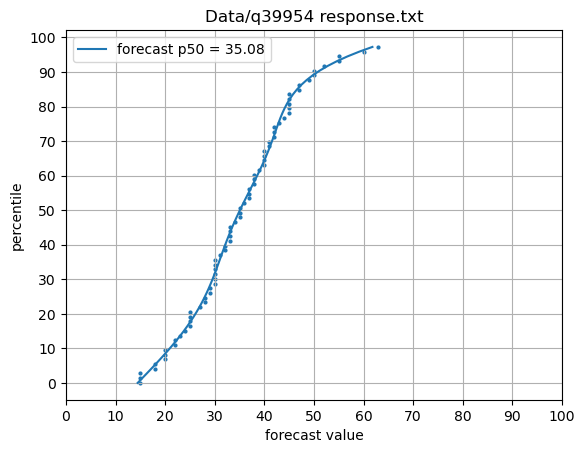

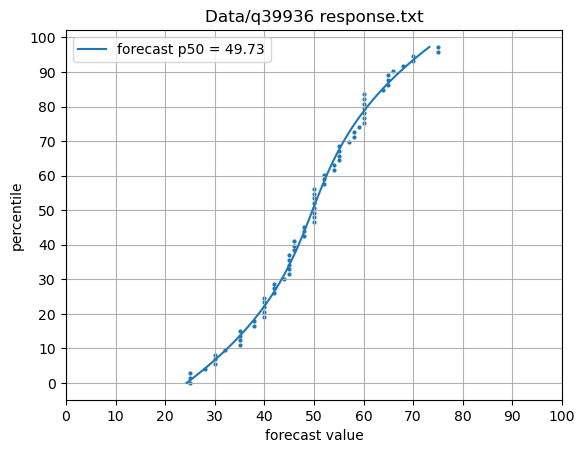

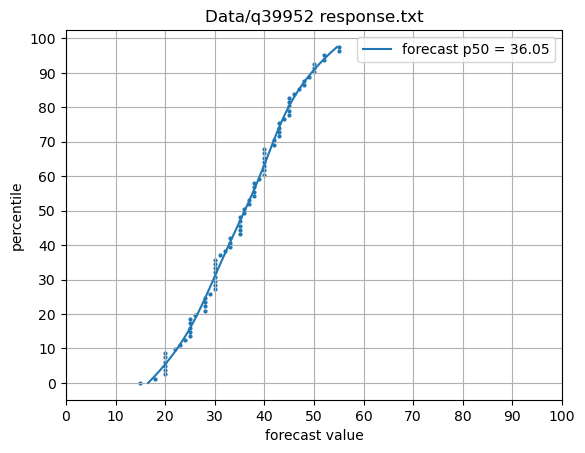

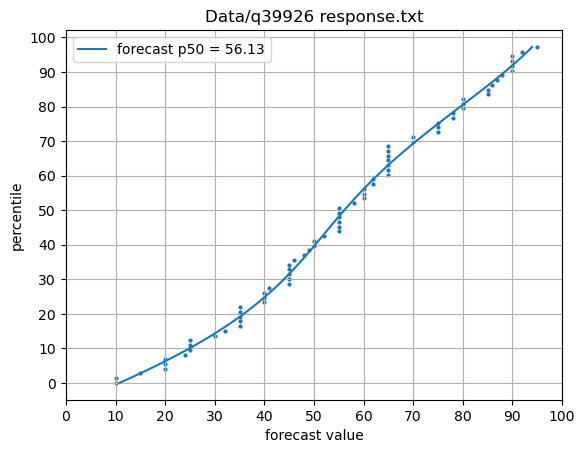

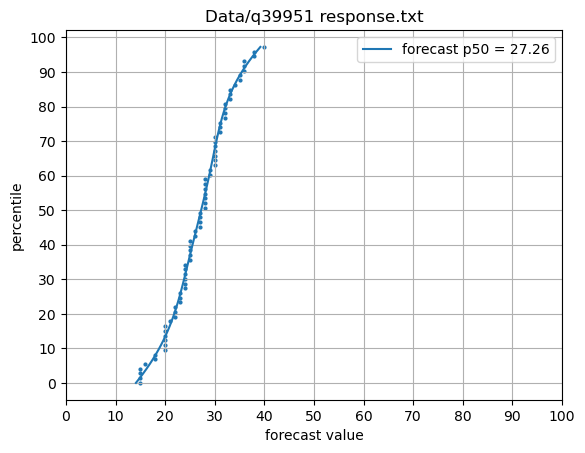

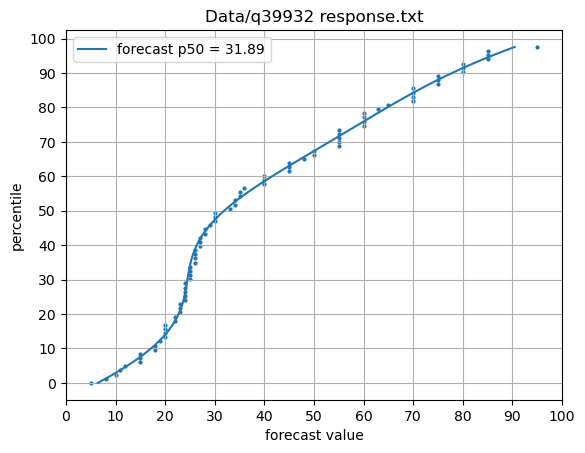

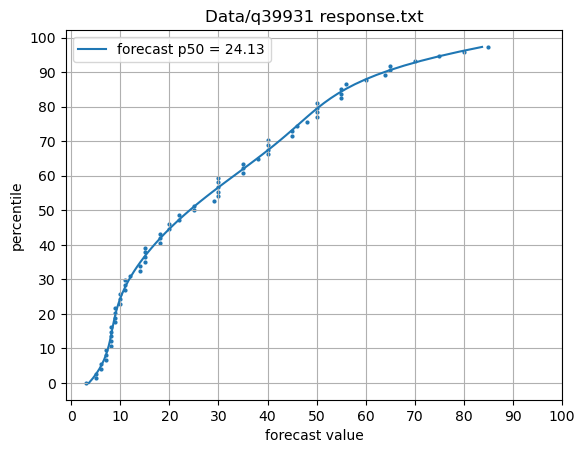

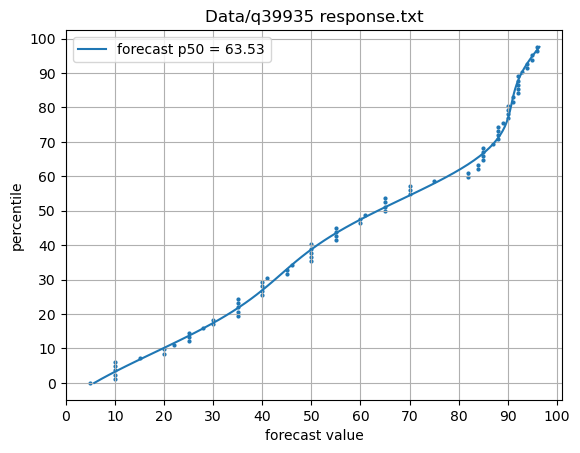

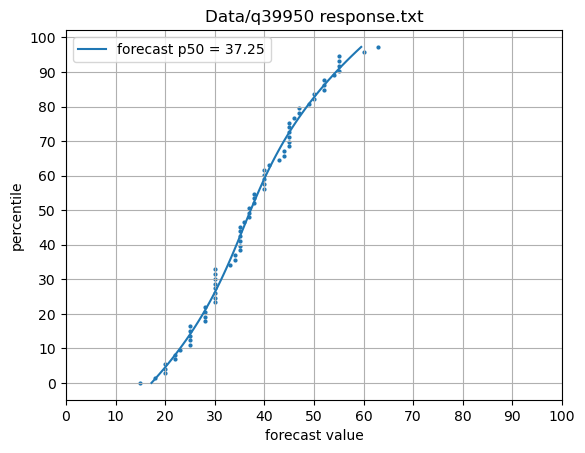

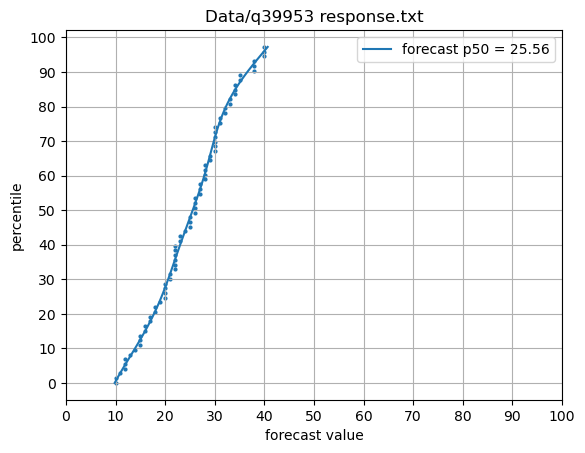

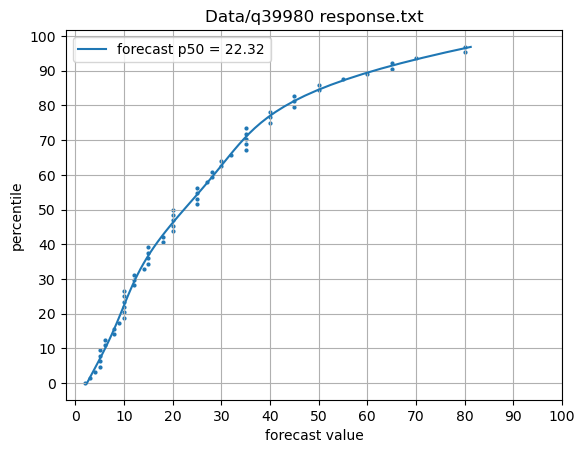

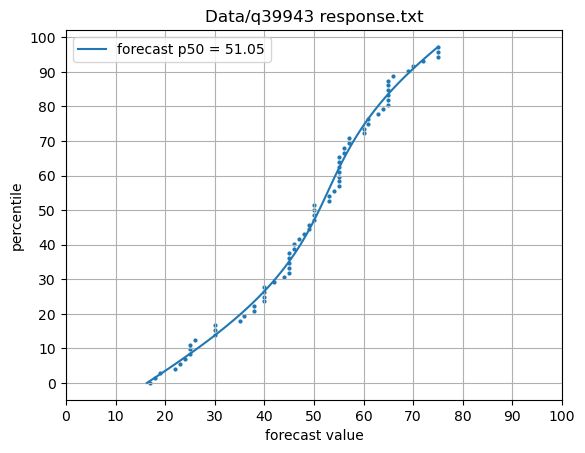

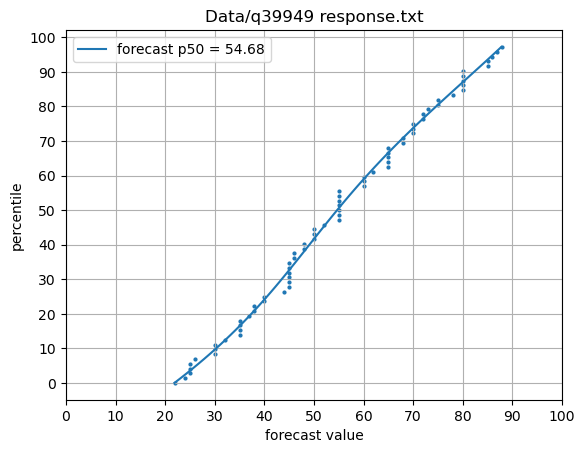

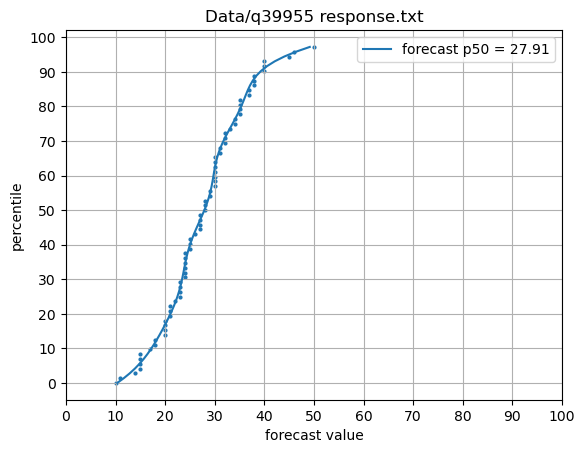

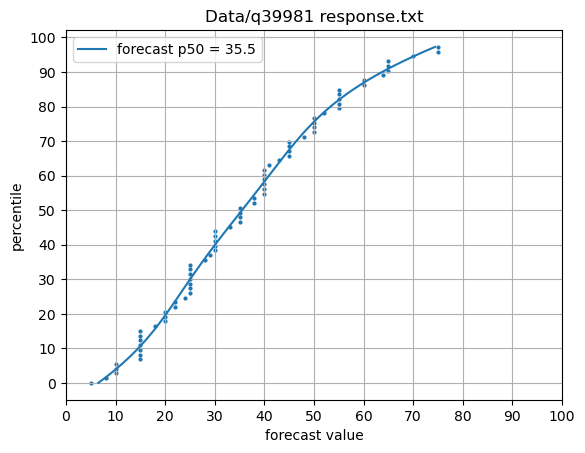

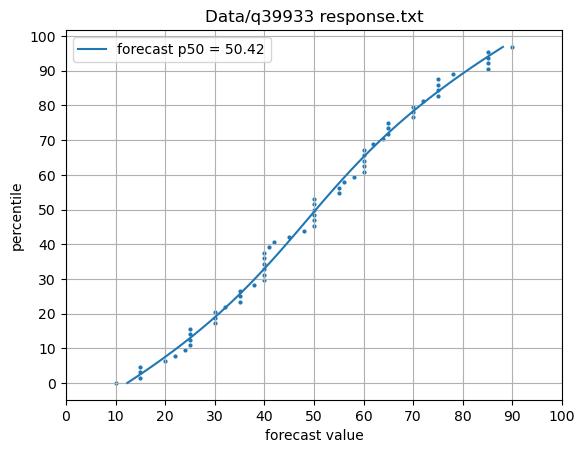

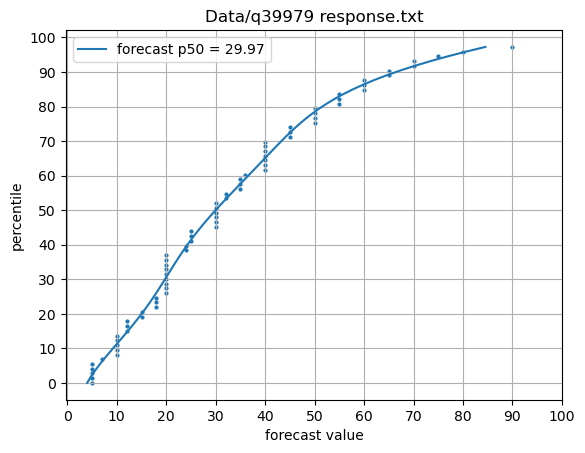

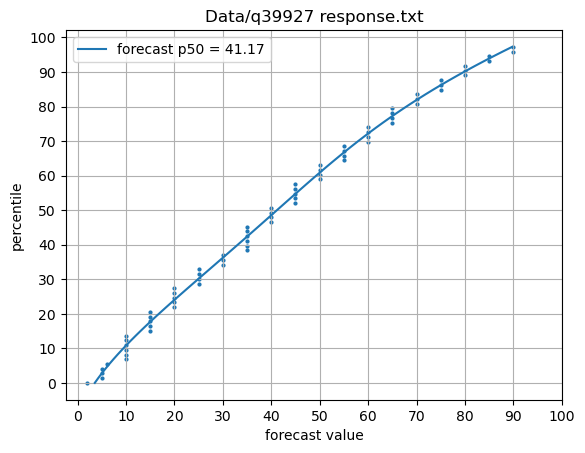

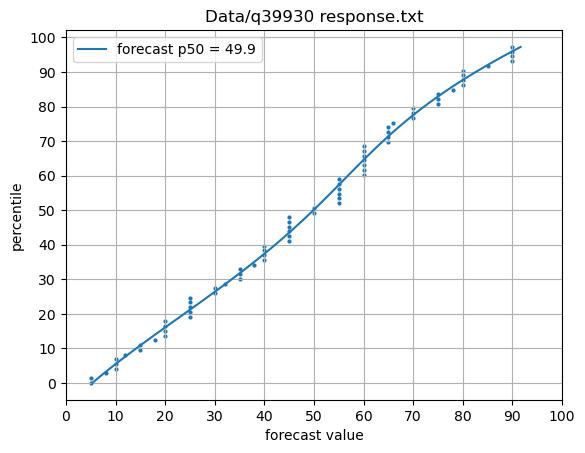

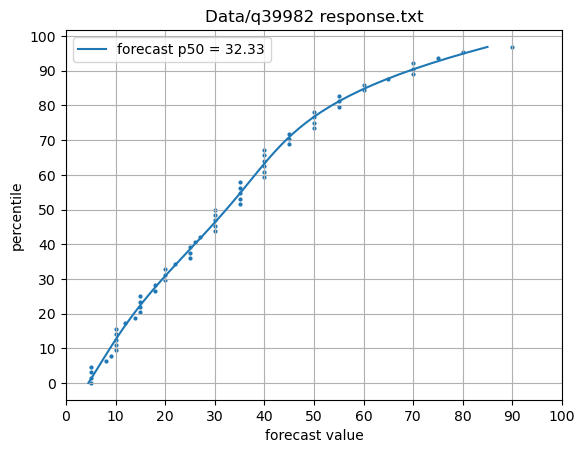

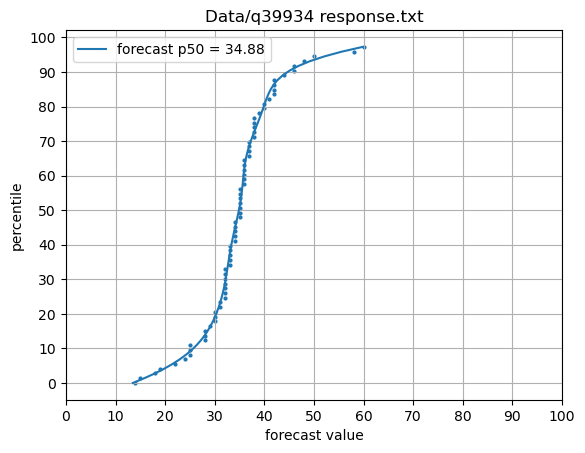

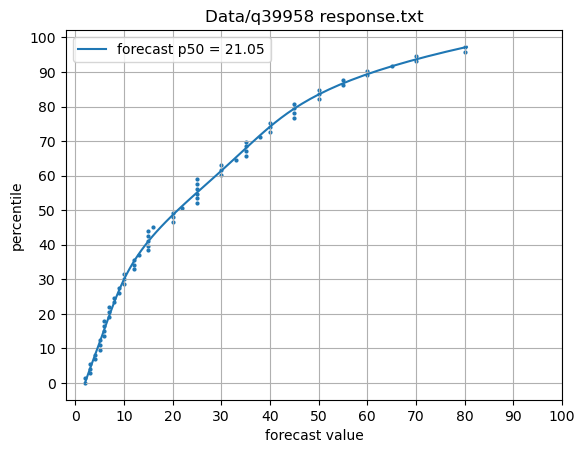

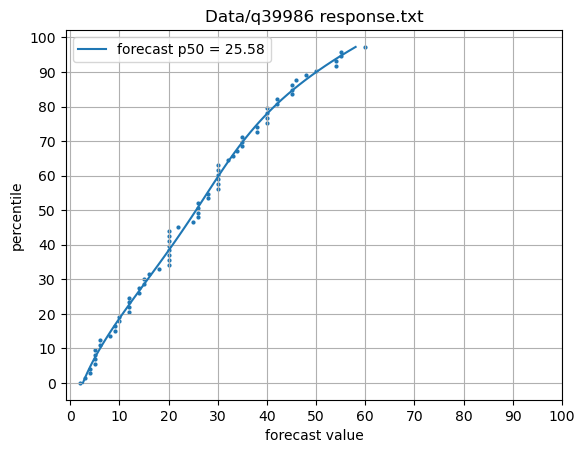

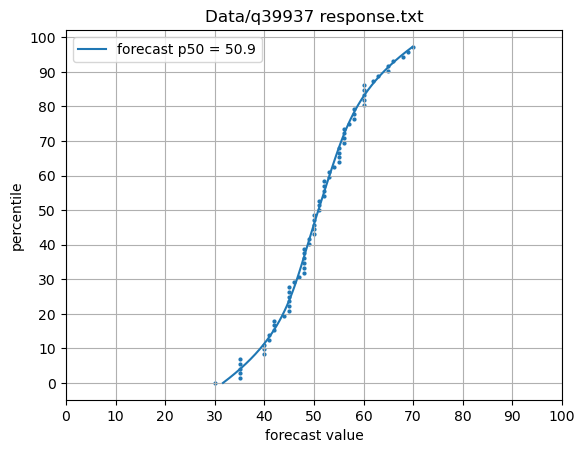

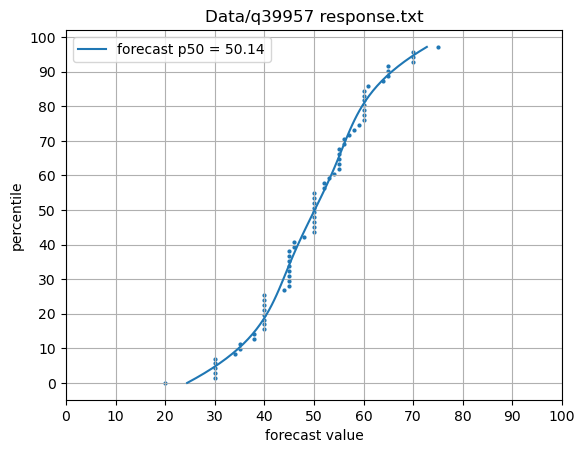

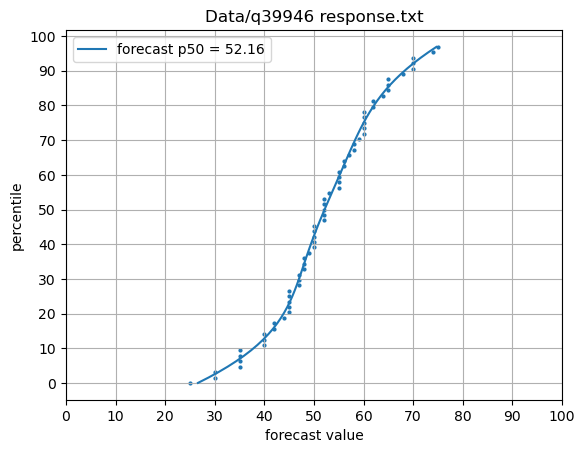

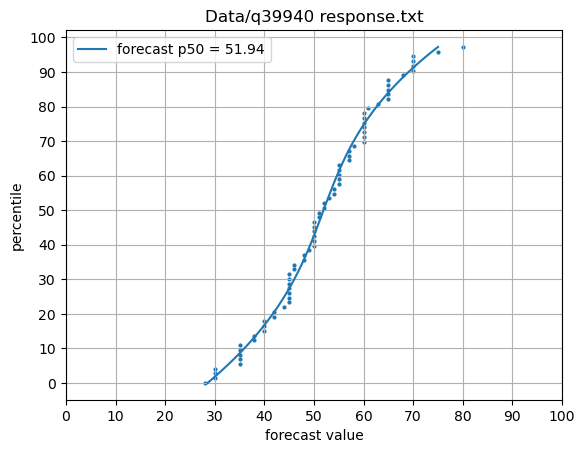

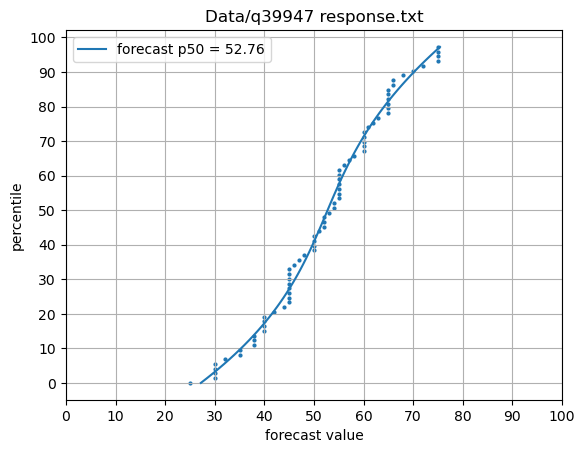

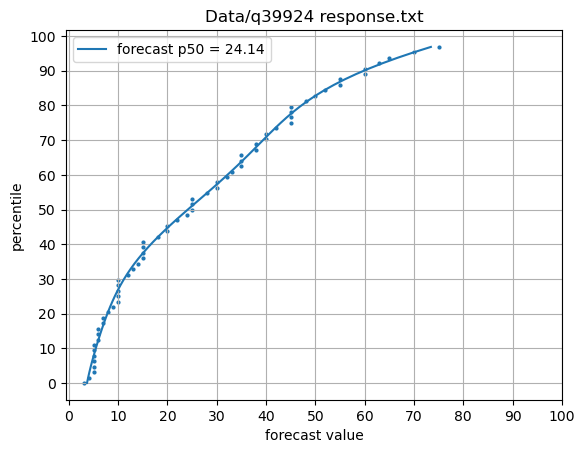

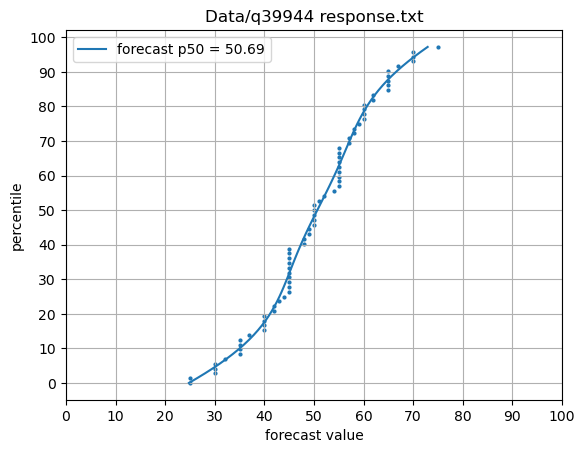

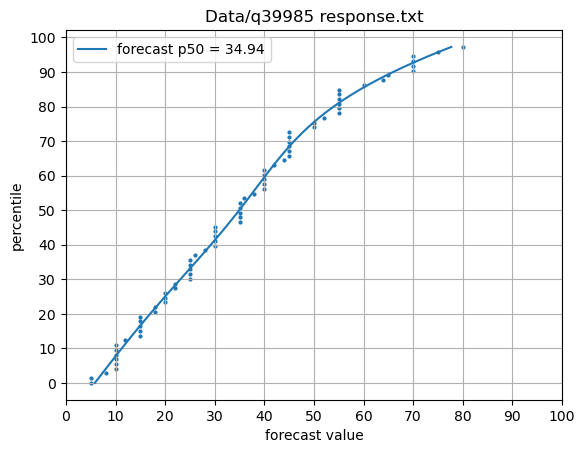

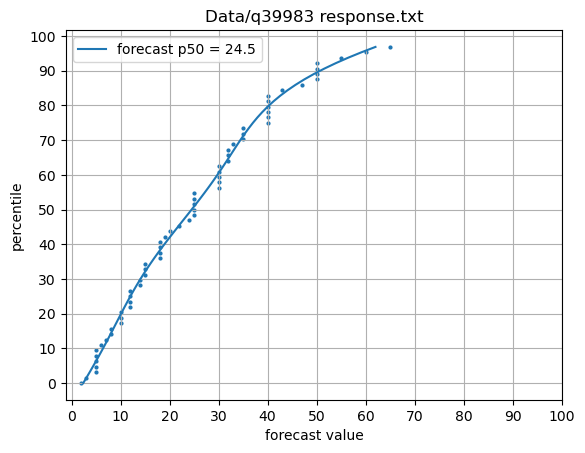

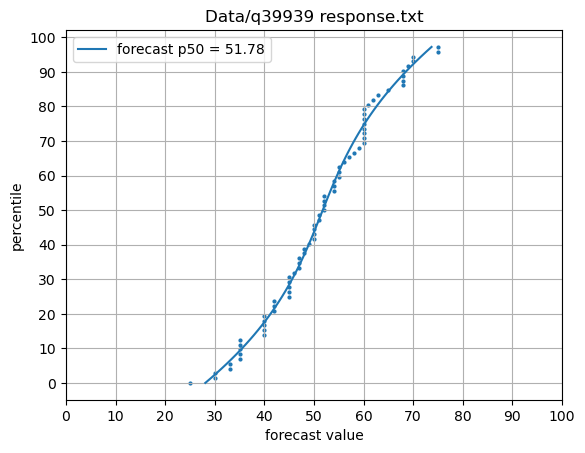

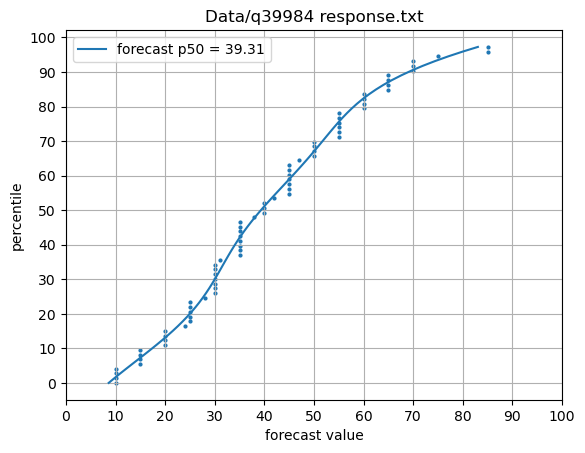

C:\Users\Donni\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


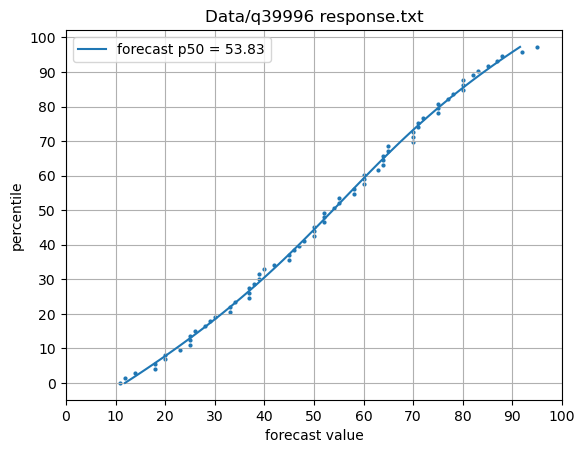

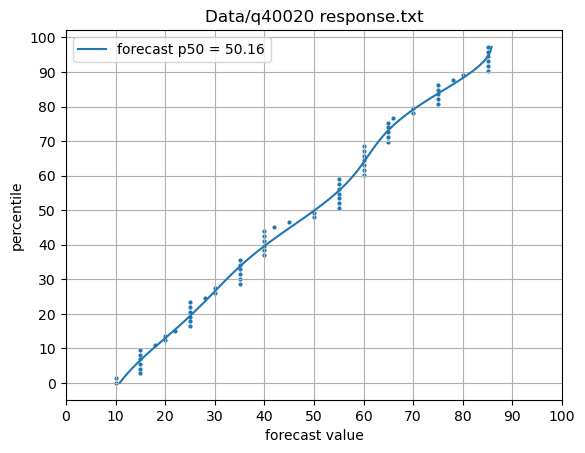

In [6]:
# Extract-Fit-Plot scripts
for q in question_ids:
    text_file = f"q{q} response.txt"
    file = path + "/" + text_file
    #print("\n",file)
    extracted_lines = extract_data_lines(file, pattern)
    #print(extracted_lines)
    cleaned_data = clean_data(extracted_lines)
    #print(cleaned_data)
    sorted_data = make_sorted_single_lst(cleaned_data)
    #print(sorted_data)
    pctl = make_percentiles(sorted_data)
    #print(pctl)
    gpr_model = make_gpr_model(sorted_data, pctl)
    forecast_p50 = gpr_model.predict(np.array([50]).reshape(-1,1))
    predicted_val = gpr_model.predict(np.array(pctl).reshape(-1,1))
    plot_forecast()